<a href="https://colab.research.google.com/github/saulotorres7031-stack/Tareas1/blob/main/Wheater.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [17]:
# Paquetería básica
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Importamos Tensorflow y Keras
import tensorflow as tf
from tensorflow import keras

# Usamos funcionalidades básicas de Sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


In [18]:
!wget 'https://github.com/Dr-Carlos-Villasenor/Clase_Aprendizaje_Profundo/raw/main/Datasets/weatherHistory.csv'

--2026-03-14 19:35:30--  https://github.com/Dr-Carlos-Villasenor/Clase_Aprendizaje_Profundo/raw/main/Datasets/weatherHistory.csv
Resolving github.com (github.com)... 20.205.243.166
Connecting to github.com (github.com)|20.205.243.166|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/Dr-Carlos-Villasenor/Clase_Aprendizaje_Profundo/main/Datasets/weatherHistory.csv [following]
--2026-03-14 19:35:30--  https://raw.githubusercontent.com/Dr-Carlos-Villasenor/Clase_Aprendizaje_Profundo/main/Datasets/weatherHistory.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.109.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 16294377 (16M) [text/plain]
Saving to: ‘weatherHistory.csv.1’

weatherHistory.csv. 100%[===================>]  15.54M  --.-KB/s    in 0.03s 

In [19]:
dataset = pd.read_csv('weatherHistory.csv')
dataset.head()

,Formatted Date,Summary,Precip Type,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Loud Cover,Pressure (millibars),Daily Summary
0,2006-04-01 00:00:00.000 +0200,Partly Cloudy,rain,9.472222,7.388889,0.89,14.1197,251.0,15.8263,0.0,1015.13,Partly cloudy throughout the day.
1,2006-04-01 01:00:00.000 +0200,Partly Cloudy,rain,9.355556,7.227778,0.86,14.2646,259.0,15.8263,0.0,1015.63,Partly cloudy throughout the day.
2,2006-04-01 02:00:00.000 +0200,Mostly Cloudy,rain,9.377778,9.377778,0.89,3.9284,204.0,14.9569,0.0,1015.94,Partly cloudy throughout the day.
3,2006-04-01 03:00:00.000 +0200,Partly Cloudy,rain,8.288889,5.944444,0.83,14.1036,269.0,15.8263,0.0,1016.41,Partly cloudy throughout the day.
4,2006-04-01 04:00:00.000 +0200,Mostly Cloudy,rain,8.755556,6.977778,0.83,11.0446,259.0,15.8263,0.0,1016.51,Partly cloudy throughout the day.


In [20]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96453 entries, 0 to 96452
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Formatted Date            96453 non-null  object 
 1   Summary                   96453 non-null  object 
 2   Precip Type               95936 non-null  object 
 3   Temperature (C)           96453 non-null  float64
 4   Apparent Temperature (C)  96453 non-null  float64
 5   Humidity                  96453 non-null  float64
 6   Wind Speed (km/h)         96453 non-null  float64
 7   Wind Bearing (degrees)    96453 non-null  float64
 8   Visibility (km)           96453 non-null  float64
 9   Loud Cover                96453 non-null  float64
 10  Pressure (millibars)      96453 non-null  float64
 11  Daily Summary             96453 non-null  object 
dtypes: float64(8), object(4)
memory usage: 8.8+ MB


In [21]:
np.array(dataset)

array([['2006-04-01 00:00:00.000 +0200', 'Partly Cloudy', 'rain', ...,
        0.0, 1015.13, 'Partly cloudy throughout the day.'],
       ['2006-04-01 01:00:00.000 +0200', 'Partly Cloudy', 'rain', ...,
        0.0, 1015.63, 'Partly cloudy throughout the day.'],
       ['2006-04-01 02:00:00.000 +0200', 'Mostly Cloudy', 'rain', ...,
        0.0, 1015.94, 'Partly cloudy throughout the day.'],
       ...,
       ['2016-09-09 21:00:00.000 +0200', 'Partly Cloudy', 'rain', ...,
        0.0, 1015.66, 'Partly cloudy starting in the morning.'],
       ['2016-09-09 22:00:00.000 +0200', 'Partly Cloudy', 'rain', ...,
        0.0, 1015.95, 'Partly cloudy starting in the morning.'],
       ['2016-09-09 23:00:00.000 +0200', 'Partly Cloudy', 'rain', ...,
        0.0, 1016.16, 'Partly cloudy starting in the morning.']],
      dtype=object)

Encontrar variables de columnas

In [22]:
dataset['Summary'].unique()

array(['Partly Cloudy', 'Mostly Cloudy', 'Overcast', 'Foggy',
       'Breezy and Mostly Cloudy', 'Clear', 'Breezy and Partly Cloudy',
       'Breezy and Overcast', 'Humid and Mostly Cloudy',
       'Humid and Partly Cloudy', 'Windy and Foggy', 'Windy and Overcast',
       'Breezy and Foggy', 'Windy and Partly Cloudy', 'Breezy',
       'Dry and Partly Cloudy', 'Windy and Mostly Cloudy',
       'Dangerously Windy and Partly Cloudy', 'Dry', 'Windy',
       'Humid and Overcast', 'Light Rain', 'Drizzle', 'Windy and Dry',
       'Dry and Mostly Cloudy', 'Breezy and Dry', 'Rain'], dtype=object)

In [23]:
dataset['Precip Type'].unique()

array(['rain', 'snow', nan], dtype=object)

In [24]:
dataset['Daily Summary'].unique()

array(['Partly cloudy throughout the day.',
       'Mostly cloudy throughout the day.', 'Foggy in the evening.',
       'Foggy overnight and breezy in the morning.',
       'Overcast throughout the day.', 'Partly cloudy until night.',
       'Mostly cloudy until night.',
       'Foggy starting overnight continuing until morning.',
       'Foggy in the morning.', 'Partly cloudy until evening.',
       'Partly cloudy starting in the morning.',
       'Mostly cloudy starting overnight continuing until night.',
       'Mostly cloudy until evening.',
       'Partly cloudy starting in the morning continuing until evening.',
       'Partly cloudy starting in the afternoon.',
       'Partly cloudy starting overnight.',
       'Partly cloudy until morning.',
       'Partly cloudy starting overnight continuing until night.',
       'Partly cloudy starting in the afternoon continuing until night.',
       'Mostly cloudy starting overnight.',
       'Partly cloudy until afternoon.',
       'Mostly

Retirar columnas no relevantes


In [25]:
dataset = dataset.drop(columns=['Formatted Date','Daily Summary'])

In [26]:
np.array(dataset)

array([['Partly Cloudy', 'rain', 9.47222222222222, ...,
        15.826300000000002, 0.0, 1015.13],
       ['Partly Cloudy', 'rain', 9.355555555555558, ...,
        15.826300000000002, 0.0, 1015.63],
       ['Mostly Cloudy', 'rain', 9.377777777777778, ..., 14.9569, 0.0,
        1015.94],
       ...,
       ['Partly Cloudy', 'rain', 22.03888888888889, ..., 16.1, 0.0,
        1015.66],
       ['Partly Cloudy', 'rain', 21.522222222222226, ..., 16.1, 0.0,
        1015.95],
       ['Partly Cloudy', 'rain', 20.438888888888894, ...,
        15.520400000000002, 0.0, 1016.16]], dtype=object)

Dummies

In [27]:
dataset = pd.get_dummies(dataset,
                         columns=['Summary','Precip Type'])

In [28]:
np.array(dataset)

array([[9.47222222222222, 7.388888888888887, 0.89, ..., False, True,
        False],
       [9.355555555555558, 7.227777777777776, 0.86, ..., False, True,
        False],
       [9.377777777777778, 9.377777777777778, 0.89, ..., False, True,
        False],
       ...,
       [22.03888888888889, 22.03888888888889, 0.56, ..., False, True,
        False],
       [21.522222222222226, 21.522222222222226, 0.6, ..., False, True,
        False],
       [20.438888888888894, 20.438888888888894, 0.61, ..., False, True,
        False]], dtype=object)

Variables de entrada y salida

In [29]:
x = np.asanyarray(dataset.drop(columns=['Visibility (km)']))
y = np.asanyarray(dataset[['Visibility (km)']])
x = StandardScaler().fit_transform(x)
print(x.shape)
print(y.shape)

(96453, 36)
(96453, 1)


Particiona el dataset

In [30]:
xtrain, xtest, ytrain, ytest = train_test_split(x, y, test_size=0.2)

Red neuronal para aprender los datos. En este caso creamos la metrica de regresión R2,

In [31]:
def build_model():

  model = keras.Sequential()
  model.add(keras.layers.Dense(128, activation='relu', input_shape=[x.shape[1]]))
  model.add(keras.layers.Dense(64, activation='relu'))
  #model.add(keras.layers.Dropout(0.4))
  model.add(keras.layers.Dense(32, activation='relu'))
  #model.add(keras.layers.Dropout(0.6))
  model.add(keras.layers.Dense(1, activation='linear'))

  model.compile(
    loss='mean_squared_error',
    optimizer=keras.optimizers.Adam(),
    metrics=[
        keras.metrics.MeanAbsoluteError(),
        keras.metrics.R2Score(name='r2_score')])
  return  model

In [32]:
es = keras.callbacks.EarlyStopping(monitor='val_loss', mode='min', patience=80)

model = build_model()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Entrenar la red neuronal sin Early Stopping

In [33]:
history = model.fit(xtrain, ytrain,
                    batch_size=150, epochs=500,
                    validation_data=(xtest, ytest), verbose=0)

Dibuja las curvas de aprendizaje para un mejor diagnóstico del aprendizaje

In [34]:
def plot_history(history):
  hist = pd.DataFrame(history.history)
  hist['epoch'] = history.epoch
  plt.figure()
  plt.subplot(121)
  plt.title('Loss')
  plt.xlabel('Epoch')
  plt.ylabel('Loss')
  plt.plot(hist['epoch'], hist['loss'],
           label='Train')
  plt.plot(hist['epoch'], hist['val_loss'],
           label = 'Val')
  plt.yscale('log')
  plt.legend()

  plt.subplot(122)
  plt.title('R2 Score')
  plt.xlabel('Epoch')
  plt.ylabel('r2score')
  plt.plot(hist['epoch'], hist['r2_score'],
           label='Train')
  plt.plot(hist['epoch'], hist['val_r2_score'],
           label = 'Val')
  plt.ylim([0,1])
  plt.legend()

129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 7.9591 - mean_absolute_error: 2.1671 - r2_score: 0.5472
Loss: 7.959072589874268
MAE: 2.1671242713928223
R2: 0.5471696853637695
515/515 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 5.9684 - mean_absolute_error: 1.9558 - r2_score: 0.6604
Train Loss: 5.968371391296387
Train MAE: 1.9558228254318237
Train R2: 0.6603649854660034


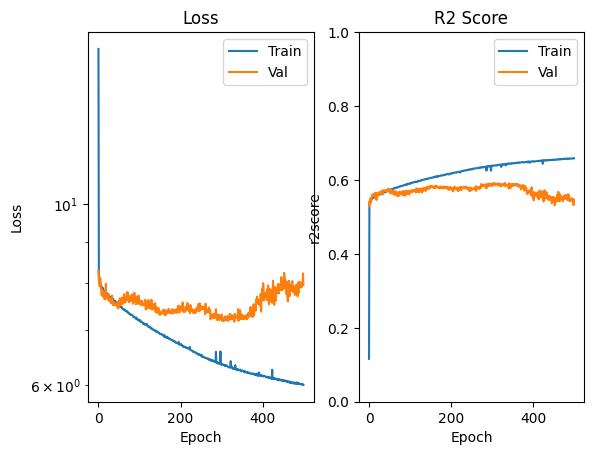

In [35]:

plot_history(history)

loss, mae, r2 = model.evaluate(xtest, ytest, batch_size=150)

print("Loss:", loss)
print("MAE:", mae)
print("R2:", r2)

loss, mae, r2 = model.evaluate(xtrain, ytrain, batch_size=150)

print("Train Loss:", loss)
print("Train MAE:", mae)
print("Train R2:", r2)

Con Early Stopping

In [36]:
model2 = build_model()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [37]:
history2 = model2.fit(xtrain, ytrain,
                    batch_size=150, epochs=500,
                    validation_data=(xtest, ytest),
                    verbose=0, callbacks=[es])

129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 8.4333 - mean_absolute_error: 2.0945 - r2_score: 0.5202
Loss: 8.433310508728027
MAE: 2.0945231914520264
R2: 0.5201879739761353
515/515 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 6.4312 - mean_absolute_error: 1.9857 - r2_score: 0.6340
Train Loss: 6.431214332580566
Train MAE: 1.9857290983200073
Train R2: 0.6340265274047852


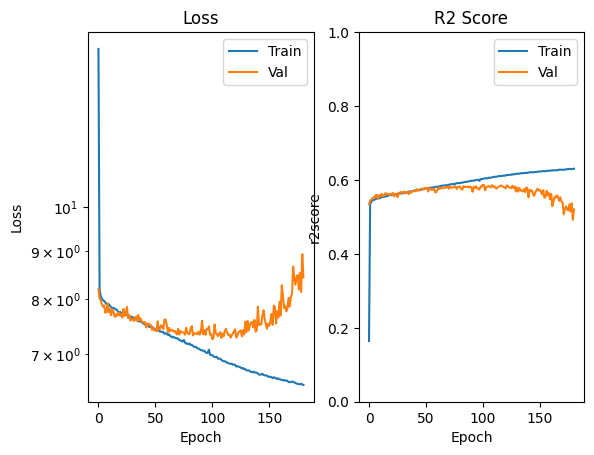

In [38]:
plot_history(history2)

loss, mae, r2 = model2.evaluate(xtest, ytest, batch_size=150)

print("Loss:", loss)
print("MAE:", mae)
print("R2:", r2)

loss, mae, r2 = model2.evaluate(xtrain, ytrain, batch_size=150)

print("Train Loss:", loss)
print("Train MAE:", mae)
print("Train R2:", r2)